In [ ]:
from pathlib import Path
from PIL import ImageOps

import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder


# =========================
# Config
# =========================

PROJECT_ROOT = Path.home() / "DCT_ViT"
DATA_ROOT = PROJECT_ROOT / "dataset"

TRAIN_ROOT = DATA_ROOT / "train.X1"
VAL_ROOT = DATA_ROOT / "val.X"

INPUT_SIZE = 224  # 나중에 256, 384 등 8의 배수로 변경 가능
BATCH_SIZE = 32
NUM_WORKERS = 4

assert INPUT_SIZE % 8 == 0, "INPUT_SIZE must be divisible by 8 for 8x8 DCT blocks."


# =========================
# Resize with Padding
# =========================

class ResizeWithPadding:
    def __init__(self, size: int, fill=0):
        assert size % 8 == 0, "size must be divisible by 8."
        self.size = size
        self.fill = fill

    def __call__(self, img):
        # RGB 통일
        img = img.convert("RGB")

        # 비율 유지하면서 긴 변을 size 이하로 축소/확대
        img.thumbnail((self.size, self.size))

        w, h = img.size
        pad_w = self.size - w
        pad_h = self.size - h

        padding = (
            pad_w // 2,
            pad_h // 2,
            pad_w - pad_w // 2,
            pad_h - pad_h // 2,
        )

        img = ImageOps.expand(img, padding, fill=self.fill)
        return img


# =========================
# Transforms
# =========================

train_transform = transforms.Compose([
    ResizeWithPadding(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    ResizeWithPadding(INPUT_SIZE),
    transforms.ToTensor(),
])


# =========================
# Dataset
# =========================

train_dataset = ImageFolder(
    root=TRAIN_ROOT,
    transform=train_transform,
)

val_dataset = ImageFolder(
    root=VAL_ROOT,
    transform=val_transform,
)


# =========================
# DataLoader
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)


# =========================
# Test
# =========================

images, labels = next(iter(train_loader))

print("Train images:", images.shape)
print("Train labels:", labels.shape)
print("Num train samples:", len(train_dataset))
print("Num val samples:", len(val_dataset))
print("Num classes:", len(train_dataset.classes))
print("First classes:", train_dataset.classes[:10])

Train images: torch.Size([32, 3, 224, 224])
Train labels: torch.Size([32])
Num train samples: 32500
Num val samples: 5000
Num classes: 25
First classes: ['n01440764', 'n01484850', 'n01494475', 'n01531178', 'n01632777', 'n01665541', 'n01687978', 'n01695060', 'n01749939', 'n01775062']


In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder

# timm (ViT 모델)
import timm

# OpenCV (YCbCr 변환 등)
import cv2

# DCT 처리
from scipy.fftpack import dct, idct

# 진행률 표시
from tqdm import tqdm

# 경로 및 파일 처리
from pathlib import Path
import os

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# 프로젝트 / 데이터 경로
PROJECT_ROOT = Path.home() / "DCT_ViT"
DATA_ROOT = PROJECT_ROOT / "dataset"

TRAIN_ROOTS = [
    DATA_ROOT / "train.X1",
    DATA_ROOT / "train.X2",
    DATA_ROOT / "train.X3",
    DATA_ROOT / "train.X4",
]
VAL_ROOT = DATA_ROOT / "val.X"

# 경로 존재 확인
assert PROJECT_ROOT.exists(), f"Project root not found: {PROJECT_ROOT}"
assert DATA_ROOT.exists(), f"Dataset root not found: {DATA_ROOT}"

for train_root in TRAIN_ROOTS:
    assert train_root.exists(), f"Train root not found: {train_root}"

assert VAL_ROOT.exists(), f"Validation root not found: {VAL_ROOT}"


# 이미지 파일 경로 수집
train_image_files = []

for train_root in TRAIN_ROOTS:
    train_image_files.extend(sorted(train_root.rglob("*.jpeg")))

val_image_files = sorted(VAL_ROOT.rglob("*.jpeg"))

# 파일 개수 확인
print("Train image files:", len(train_image_files))
print("Validation image files:", len(val_image_files))


# 앞의 몇 개 파일 경로 출력
print("\nFirst train image files:")
for i, path in enumerate(train_image_files[:10]):
    print(f"{i}: {path}")


# PIL로 실제 이미지 읽기
sample_path = train_image_files[0]

img = Image.open(sample_path)

print("\nSample image path:", sample_path)
print("Image type:", type(img))
print("Image mode:", img.mode)
print("Image size:", img.size)

Train image files: 0
Validation image files: 0

First train image files:


IndexError: list index out of range

In [ ]:
# =========================================================
# 1. 기본 설정
# =========================================================

# 프로젝트 최상위 폴더 경로
PROJECT_ROOT = Path.home() / "DCT_ViT"

# 데이터셋 폴더 경로
DATA_ROOT = PROJECT_ROOT / "dataset"

# 학습 / 검증 데이터 경로
TRAIN_ROOT = DATA_ROOT / "train.X1"
VAL_ROOT = DATA_ROOT / "val.X"

# 입력 이미지 크기
# DCT 8x8 block 사용 예정이므로 8의 배수 권장
INPUT_SIZE = 224

# 배치 크기
BATCH_SIZE = 32

# DataLoader 병렬 프로세스 개수
NUM_WORKERS = 4

# 입력 크기가 8의 배수인지 확인
assert INPUT_SIZE % 8 == 0

In [ ]:
# =========================================================
# 2. 비율 유지 + padding resize
# =========================================================

class ResizeWithPadding:
    """
    이미지를 비율 유지한 채 resize 후,
    부족한 부분은 padding으로 채워
    최종적으로 정사각형 이미지 생성
    """

    def __init__(self, size=224, fill=0):

        # 최종 이미지 크기
        self.size = size

        # padding 색상 (0 = 검정)
        self.fill = fill

    def __call__(self, img):

        # RGB 형식 통일
        img = img.convert("RGB")

        # 비율 유지 resize
        # 긴 변 기준으로 self.size 안에 들어오도록 조정
        img.thumbnail((self.size, self.size))

        # 현재 이미지 크기
        w, h = img.size

        # padding 크기 계산
        pad_w = self.size - w
        pad_h = self.size - h

        # (left, top, right, bottom)
        padding = (
            pad_w // 2,
            pad_h // 2,
            pad_w - pad_w // 2,
            pad_h - pad_h // 2
        )

        # padding 추가
        img = ImageOps.expand(
            img,
            border=padding,
            fill=self.fill
        )

        return img


# =========================================================
# 3. RGB -> YCbCr 변환
# =========================================================

class RGBToYCbCr:
    """
    RGB 이미지를 YCbCr 색공간으로 변환

    입력:
        Tensor [3, H, W]
        RGB 순서
        값 범위 [0, 1]

    출력:
        Tensor [3, H, W]
        채널 순서 [Y, Cb, Cr]
    """

    def __call__(self, img: torch.Tensor):

        # RGB 채널 분리
        r = img[0]
        g = img[1]
        b = img[2]

        # Y 채널
        y = (
            0.299 * r +
            0.587 * g +
            0.114 * b
        )

        # Cb 채널
        cb = (
            -0.168736 * r
            -0.331264 * g
            +0.5 * b
            +0.5
        )

        # Cr 채널
        cr = (
            +0.5 * r
            -0.418688 * g
            -0.081312 * b
            +0.5
        )

        # 채널 결합
        return torch.stack([y, cb, cr], dim=0)


# =========================================================
# 4. 이미지 전처리 정의
# =========================================================

train_transform = transforms.Compose([

    # 비율 유지 resize + padding
    ResizeWithPadding(INPUT_SIZE),

    # Tensor 변환
    # [H, W, C] -> [C, H, W]
    # 값 범위 [0,255] -> [0,1]
    transforms.ToTensor(),

    # YCbCr 변환
    RGBToYCbCr(),
])

val_transform = transforms.Compose([
    ResizeWithPadding(INPUT_SIZE),
    transforms.ToTensor(),
    RGBToYCbCr(),
])


# =========================================================
# 5. 데이터셋 불러오기
# =========================================================

# ImageFolder:
# 폴더 이름을 자동으로 class label로 사용

train_dataset = ImageFolder(
    root=TRAIN_ROOT,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=VAL_ROOT,
    transform=val_transform
)


# =========================================================
# 6. DataLoader 생성
# =========================================================

train_loader = DataLoader(

    # 사용할 dataset
    train_dataset,

    # batch 크기
    batch_size=BATCH_SIZE,

    # 데이터 섞기
    shuffle=True,

    # 병렬 데이터 로딩
    num_workers=NUM_WORKERS,

    # GPU 전송 최적화
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# =========================================================
# 7. 테스트용 batch 확인
# =========================================================

# 첫 번째 batch 가져오기
images, labels = next(iter(train_loader))

# shape 출력
print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

# 데이터셋 크기 출력
print("Train samples :", len(train_dataset))
print("Validation samples :", len(val_dataset))

# 클래스 개수 출력
print("Number of classes :", len(train_dataset.classes))

# 일부 클래스 이름 출력
print("Example classes :", train_dataset.classes[:10])

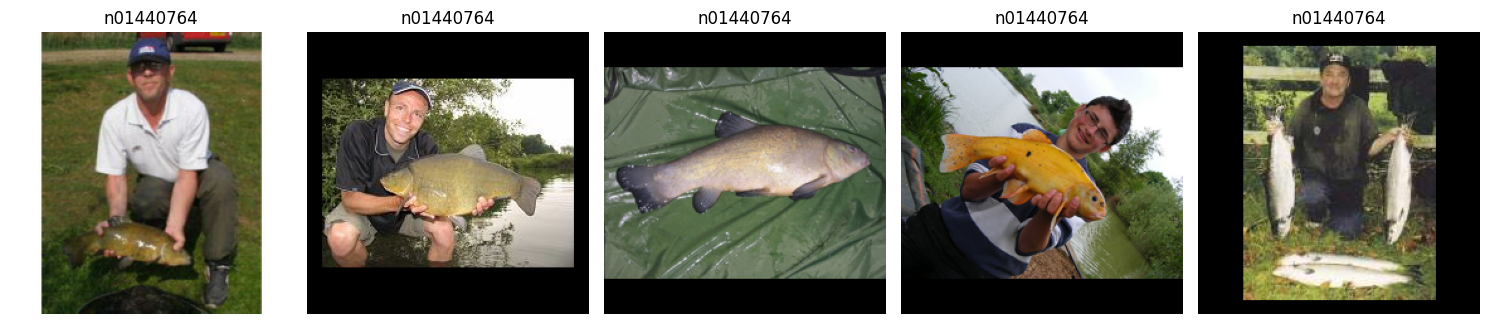

In [8]:
import matplotlib.pyplot as plt


# =========================
# Show Sample Images
# =========================

NUM_IMAGES = 5

fig, axes = plt.subplots(1, NUM_IMAGES, figsize=(15, 5))

for i in range(NUM_IMAGES):
    image, label = train_dataset[i]

    # [C, H, W] -> [H, W, C]
    image = image.permute(1, 2, 0).numpy()

    axes[i].imshow(image)
    axes[i].set_title(train_dataset.classes[label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()